Import Libraries & Load Dataset

In [1]:
%pip install numpy pandas matplotlib seaborn scikit-learn xgboost joblib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

Cell 3

Load both datasets.

In [3]:
credit = pd.read_csv("data/Credit_card.csv")

label = pd.read_csv("data/Credit_card_label.csv")

Cell 4

Merge the datasets.

In [4]:
df = pd.merge(credit, label, on="Ind_ID")

df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


Cell 5

Check dataset information.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

Cell 6

Check first five rows.

In [6]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


Cell 7

Check columns.

In [7]:
print(df.columns)

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')


Cell 8

Check missing values.

In [8]:
df.isnull().sum()

Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

Cell 9

Remove duplicate records.

In [9]:
df = df.drop_duplicates()

Cell 10
Count Plot

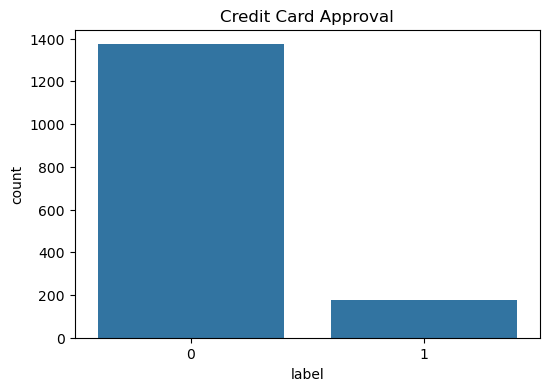

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Credit Card Approval")

plt.show()

Cell 11
Gender Distribution

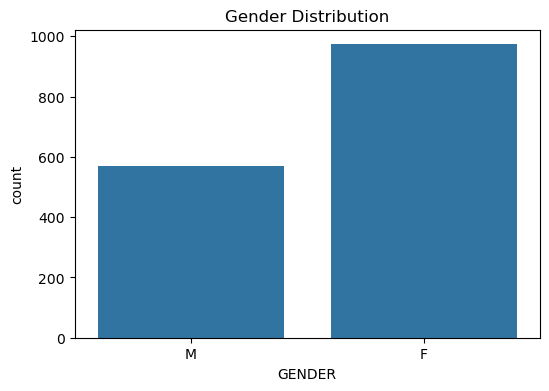

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="GENDER", data=df)

plt.title("Gender Distribution")

plt.show()

Cell 12
Income Distribution

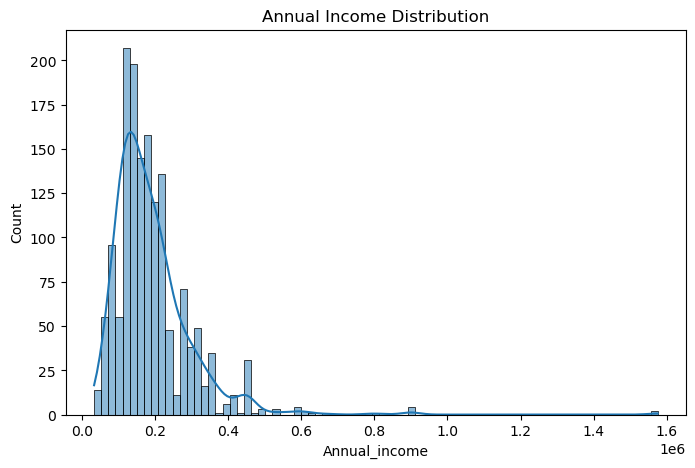

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual_income"], kde=True)

plt.title("Annual Income Distribution")

plt.show()

Cell 13
Education Level

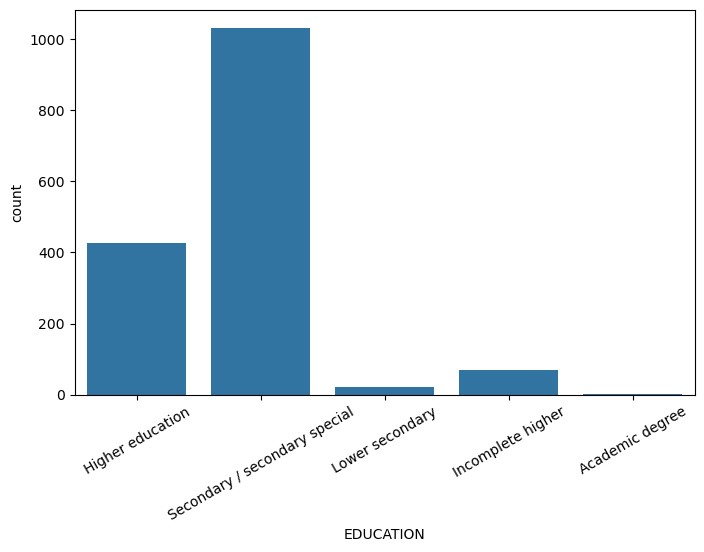

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x="EDUCATION", data=df)

plt.xticks(rotation=30)

plt.show()

Cell 14
Marital Status

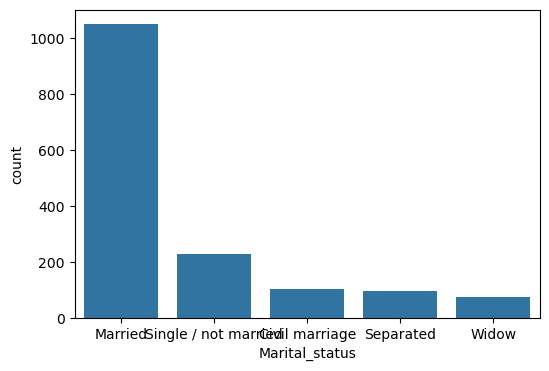

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Marital_status", data=df)

plt.show()

Cell 15
Housing Type

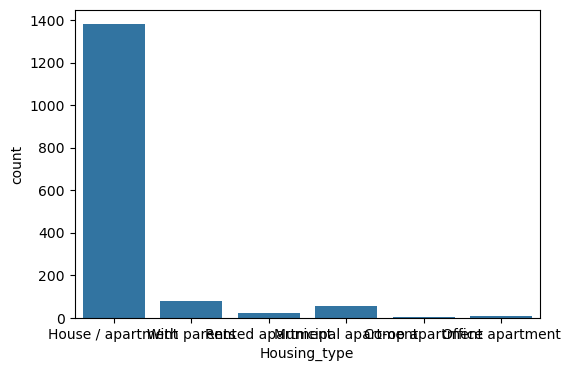

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="Housing_type", data=df)

plt.show()

Data Preprocessing & Feature Engineering

Cell 16 – Fill Missing Values

In [16]:
df.isnull().sum()

Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
label                0
dtype: int64

In [17]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

Cell 17 – Encode Categorical Columns

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

Cell 18 – Check Dataset

In [19]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,1,1,1,0,180000.0,1,1,1,1,-18772.0,365243,1,0,0,0,8,2,1
1,5009744,0,1,0,0,315000.0,0,1,1,1,-13557.0,-586,1,1,1,0,8,2,1
2,5009746,0,1,0,0,315000.0,0,1,1,1,-15661.5,-586,1,1,1,0,8,2,1
3,5009749,0,1,0,0,166500.0,0,1,1,1,-13557.0,-586,1,1,1,0,8,2,1
4,5009752,0,1,0,0,315000.0,0,1,1,1,-13557.0,-586,1,1,1,0,8,2,1


Cell 19 – Separate Features and Target

In [20]:
X = df.drop("label", axis=1)

y = df["label"]

Cell 20 – Split Dataset

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Machine Learning Models

Cell 21 – Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy :")
print(accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy :
0.9032258064516129


Cell 22 – Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy :")
print(accuracy_score(y_test, pred_dt))

Decision Tree Accuracy :
0.8838709677419355


Cell 23 – Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy :")
print(accuracy_score(y_test, pred_rf))

Random Forest Accuracy :
0.9419354838709677


Cell 24 – XGBoost

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy :")
print(accuracy_score(y_test, pred_xgb))

XGBoost Accuracy :
0.9451612903225807


Cell 25 – Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_rf)

print(cm)

[[279   1]
 [ 17  13]]


Cell 26 – Classification Report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       280
           1       0.93      0.43      0.59        30

    accuracy                           0.94       310
   macro avg       0.94      0.71      0.78       310
weighted avg       0.94      0.94      0.93       310



Cell 27 – Save Model

In [28]:
import joblib

joblib.dump(rf, "models/card_model.joblib")

print("Model Saved Successfully")

Model Saved Successfully


In [29]:
print(X.columns.tolist())
print("Total Features =", len(X.columns))

['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN', 'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members']
Total Features = 18
